# Understanding the Matrix Determinant: A Geometric View
In linear algebra, the determinant is often taught as a mechanical calculation. However, for engineers and computer scientists, it is much more useful to think of it as a scaling factor for space.

## The Core Intuition

When we multiply a vector by a square matrix A, we are performing a linear transformation. The determinant, denoted as $det(A)$, tells us how the area (in 2D) or volume (in 3D) of a shape changes after that transformation.

* If $det(A)=2$, the area of any shape is doubled.

* If $det(A)=1$, the area is preserved (though the shape might be skewed).

* If $det(A)=0$, the transformation "squashes" space into a lower dimension (e.g., a plane into a line).

* If $det(A)<0$, the orientation of the space has been flipped (a mirror image).

### The Mathematical Definition
For a square matrix $A$ of size $2 \times 2$, the determinant is defined as the difference between the products of its diagonals:

$$A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$$

$$\det(A) = |A| = ad - bc$$

For a general $n \times n$ matrix, the determinant can be computed via Laplace expansion:

$$\det(A) = \sum_{j=1}^{n} (-1)^{i+j} a_{ij} M_{ij}$$

where $M_{ij}$ is the minor of element $a_{ij}$.

### Geometric Interpretation
The determinant represents the **signed n-dimensional volume** of the n-dimensional parallelepiped defined by the column vectors of the matrix.

1. **Area Scaling:** If $V_{pre}$ is the area of a shape before transformation, the new area $V_{post}$ is:
$$V_{post} = |\det(A)| \cdot V_{pre}$$

2. **Orientation:** The sign of the determinant indicates orientation:
$$\text{sign}(\det(A)) = \begin{cases} +1 & \text{Orientation preserved} \\ -1 & \text{Orientation reversed (mirroring)} \end{cases}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_transformation(matrix, title="Transformation"):
    # Create a unit square
    square = np.array([
        [0, 0],
        [1, 0],
        [1, 1],
        [0, 1],
        [0, 0]
    ]).T

    # Apply the transformation
    transformed_square = matrix @ square

    # Calculate determinant
    det = np.linalg.det(matrix)

    # Plotting
    plt.figure(figsize=(6, 6))
    plt.plot(square[0, :], square[1, :], color='blue', label='Original (Area=1)', linestyle='--')
    plt.fill(transformed_square[0, :], transformed_square[1, :], color='orange', alpha=0.3, label=f'Transformed (Area={abs(det):.2f})')
    plt.plot(transformed_square[0, :], transformed_square[1, :], color='red')

    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.title(f"{title}\nDeterminant = {det:.2f}")
    plt.legend()
    plt.axis('equal')
    plt.show()

print("Visualization function defined.")

Visualization function defined.


## Case 1: Scaling and Stretching

Let's see a matrix that scales the x-axis by 2 and the y-axis by 1.5.
The expected area should be $2×1.5=3$.

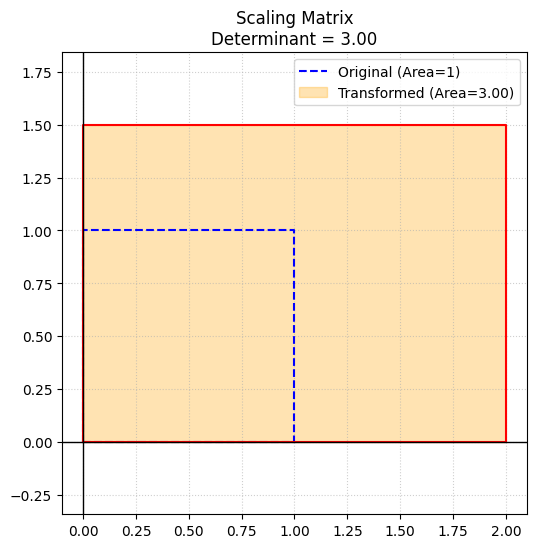

In [2]:
A = np.array([[2, 0],
              [0, 1.5]])

plot_transformation(A, "Scaling Matrix")

## Case 2: The Singular Matrix $(det=0)$

What happens if the columns of a matrix are linearly dependent? This means one dimension is lost. In the matrix below, the second column is just a multiple of the first. The 2D square will be squashed into a 1D line.

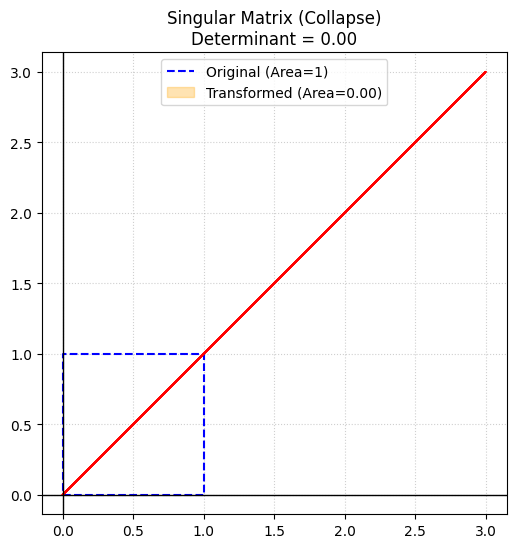

In [3]:
# The columns are [1, 1] and [2, 2]. They point in the same direction.
B = np.array([[1, 2],
              [1, 2]])

plot_transformation(B, "Singular Matrix (Collapse)")

## Why det(A)=0 Matters

From a geometric standpoint, a zero determinant means the transformation is not invertible. Once you squash a 3D cube into a 2D flat square, you have lost the information required to "expand" it back into the original cube. This is why we cannot solve systems of equations where the matrix has a zero determinant.

### Properties for Practical Use
In ML/Data Science, two properties are vital:

1. **Relation to Eigenvalues:** The determinant is the product of all eigenvalues $\lambda$ of the matrix:
$$\det(A) = \prod_{i=1}^{n} \lambda_i = \lambda_1 \lambda_2 \dots \lambda_n$$

2. **Invertibility:** A matrix is invertible (non-singular) if and only if its determinant is non-zero:
$$A^{-1} \text{ exists} \iff \det(A) \neq 0$$

If $\det(A) = 0$, the transformation collapses the space into a lower dimension, and the mapping is no longer **bijective**.